# Random Forest Tuning (Descriptors + Fingerprints)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, MACCSkeys
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors as md

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

import shap
import optuna

## Logging results

In [2]:
# Глобальный список для хранения всех результатов
all_results = []


def log_result(method_name, model_type, n_features, metrics, params=None, stage=None):
    """
    Сохраняет результаты в глобальную таблицу all_results.

    method_name — SHAP / MI / KBest / Lasso
    model_type — RF / OptunaRF / ExtraTrees / GBoost
    n_features — количество используемых фичей
    metrics — словарь метрик {"Accuracy":..., "F1":..., ...}
    params — словарь параметров модели
    stage — этап: baseline / final / optuna / simple_tuning
    """

    record = {
        "Method": method_name,
        "Model": model_type,
        "Stage": stage,
        "Top_Features": n_features,

        # Метрики
        "Accuracy": metrics.get("Accuracy"),
        "Precision": metrics.get("Precision"),
        "Recall": metrics.get("Recall"),
        "F1": metrics.get("F1"),
        "ROC_AUC": metrics.get("AUC"),
    }

    # Добавляем параметры модели, если есть
    if params is not None:
        for key, value in params.items():
            record[f"Param_{key}"] = value

    all_results.append(record)


def save_results_table(filename="all_results.xlsx"):
    """
    Преобразует global all_results → DataFrame и сохраняет таблицу.
    """
    df = pd.DataFrame(all_results)
    df.to_excel(filename, index=False)
    print(f"Saved full results table to {filename}")
    return df


## Molecule, Descriptor + Fingerprints and Outlier Functions

In [3]:
def molecule_from_smiles(smiles):
    lg = RDLogger.logger()
    # Temporarily silence RDKit logs
    lg.setLevel(RDLogger.CRITICAL)
    try:
        # Extract molecule
        molecule = Chem.MolFromSmiles(smiles, sanitize=True)
        if molecule is None:
            return None, "failed"

        # Remove salts
        clean_molecule = rdMolStandardize.LargestFragmentChooser()
        molecule = clean_molecule.choose(molecule)

        # Sanitize molecule again to reflect changes
        Chem.SanitizeMol(molecule)
        return molecule, "succeed"
    except Exception as e:
        return None, f"error: {e}"
    finally:
        # Re-enable logging afterward
        lg.setLevel(RDLogger.INFO)


def calculate_descriptors(molecule):
    # Get all descriptors (1D/2D)
    descriptor_names = []
    for descriptor, _ in Descriptors._descList:
        descriptor_names.append(descriptor)

    # Use descriptors to calculate values
    calculator = md.MolecularDescriptorCalculator(descriptor_names)
    descriptor_values = calculator.CalcDescriptors(molecule)

    # Create dictionary
    descriptors = dict(zip(descriptor_names, descriptor_values))
    return descriptors


def compute_iqr_limits(df, factor=1.5):
    # Calculate IQR limits
    limits = {}
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # If IQR is 0 - column is too flat - skip
        if iqr == 0 or np.isnan(iqr):
            continue

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        limits[col] = (lower, upper)
    return limits


def apply_iqr_limits(df, limits):
    # Apply the limits
    df_clipped = df.copy()
    for col, (lower, upper) in limits.items():
        df_clipped[col] = df_clipped[col].clip(lower, upper)
    return df_clipped


def bitvect_to_dict(fp, prefix):
    # Convert bit vector to dictionary (create features)
    n_bits = fp.GetNumBits()
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    features = {}
    for i, v in enumerate(arr):
        features[f"{prefix}_{i}"] = int(v)
    return features


def calculate_fingerprints(mol):
    RDLogger.DisableLog('rdApp.*')
    # Calculate Morgan, RDKit, MACCS, AtomPair and Topological Torsion fingerprint
    feats = {}
    if mol is None:
        return feats

    # Morgan (ECFP) fingerprint
    morgan_bits = 2048
    morgan_radius = 2
    fp_morgan = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius=morgan_radius, nBits=morgan_bits
    )
    feats.update(bitvect_to_dict(fp_morgan, f"Morgan{morgan_radius}_{morgan_bits}"))

    # RDKit topological fingerprint
    rdk_bits = 2048
    fp_rdk = Chem.RDKFingerprint(mol, fpSize=rdk_bits)
    feats.update(bitvect_to_dict(fp_rdk, f"RDK_{rdk_bits}"))

    # MACCS keys (167 bits)
    fp_maccs = MACCSkeys.GenMACCSKeys(mol)
    feats.update(bitvect_to_dict(fp_maccs, "MACCS"))

    # AtomPair fingerprint
    ap_bits = 2048
    fp_ap = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=ap_bits)
    feats.update(bitvect_to_dict(fp_ap, f"AtomPair_{ap_bits}"))

    RDLogger.EnableLog('rdApp.*')

    return feats

## Dataset Processing

In [4]:
# Configuration
ORIG_DATASET = "in_vitro_irritation.xlsx"
SKIP_ROWS = 1
SMILES_COL = "SMILES code"
TARGET_COL = "Irritation"
FULL_OUTPUT_DATASET = "in_vitro_irritation_processed.xlsx"

# Outputs
TRAIN_X_CSV = "in_vitro_irritation_x_train.csv"
TEST_X_CSV = "in_vitro_irritation_x_test.csv"
TRAIN_Y_CSV = "in_vitro_irritation_y_train.csv"
TEST_Y_CSV = "in_vitro_irritationo_y_test.csv"

# Near constant threshold - tolerance
SIMILARITY_THRESHOLD = 0.65
# Correlation threshold
CORRELATION_THRESHOLD = 0.60

dataset = pd.read_excel(ORIG_DATASET, engine="openpyxl", skiprows=SKIP_ROWS)

# --- CLEANING ---
dataset.columns = dataset.columns.str.strip()
dataset = dataset.loc[:, ~dataset.columns.str.contains("^Unnamed")]

# clean target
dataset[TARGET_COL] = dataset[TARGET_COL].astype(str).str.strip()
dataset[TARGET_COL] = dataset[TARGET_COL].replace({
    "I": 1,
    "NI": 0
})

print(dataset.columns)
print(dataset[TARGET_COL].value_counts())

descriptor_rows = []
state_molecules = []
molecules = []

for smiles in dataset[SMILES_COL].astype(str):
    molecule, state = molecule_from_smiles(smiles)
    state_molecules.append(state)
    molecules.append(molecule)

    if molecule is None:
        descriptor_rows.append({})
        continue

    # 1D/2D RDKit descriptors
    desc_feats = calculate_descriptors(molecule)

    # Calculate Morgan, RDKit, MACCS, AtomPair and Topological Torsion fingerprint
    fp_feats = calculate_fingerprints(molecule)

    # Merge both dicts into one feature row
    all_feats = {**desc_feats, **fp_feats}
    descriptor_rows.append(all_feats)

# Convert list of dictionaries into dataframe
descriptor_data_all = pd.DataFrame(descriptor_rows)

# Keep everything + status
output = pd.concat(
    [dataset.reset_index(drop=True), descriptor_data_all.reset_index(drop=True)],
    axis=1
)
output["MoleculeStatus"] = state_molecules

# Output whole dataset with descriptors and state
with pd.ExcelWriter(FULL_OUTPUT_DATASET, engine="openpyxl") as writer:
    output.to_excel(writer, index=False, sheet_name="Descriptors")

print(f"Full - Rows: {len(output)}/Columns: {output.shape[1]}")
print(output.head().to_string(index=False))

# Drop failed molecules - boolean array
molecules_right = []
for molecule in molecules:
    if molecule is not None:
        molecules_right.append(True)
    else:
        molecules_right.append(False)
if not any(molecules_right):
    raise ValueError("No valid molecules after SMILES parsing.")

dataset_ok = dataset.loc[molecules_right].reset_index(drop=True)
descriptor_ok = descriptor_data_all.loc[molecules_right].reset_index(drop=True)

# Target
# y_full = dataset_ok[TARGET_COL].astype(int)
y_full = dataset_ok[TARGET_COL]

# Take only numeric descriptor columns
X_full = descriptor_ok.select_dtypes(include=[np.number]).copy()
for column in X_full.columns:
    X_full[column] = X_full[column].replace([np.inf, -np.inf], np.nan)

# Drop columns that are entirely NaN
all_nan_cols = X_full.columns[X_full.isna().all()].tolist()
if all_nan_cols:
    print(f"Dropping {len(all_nan_cols)} NaN columns.")
    X_full = X_full.drop(columns=all_nan_cols)

# CHECK
print("Target dtype:", dataset[TARGET_COL].dtype)
print(dataset[TARGET_COL].value_counts())

# Split dataset - train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# Calculate medians for each column in train only
train_medians = X_train.median(numeric_only=True)

# Fill missing values in both train and test using those medians
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Compute constants on train only
constant_cols = []
for col in X_train.columns:
    top_freq = X_train[col].value_counts(normalize=True, dropna=False).max()
    if top_freq >= SIMILARITY_THRESHOLD:
        constant_cols.append(col)

# Drop from train and apply same drop to test
if constant_cols:
    X_train = X_train.drop(columns=constant_cols)
    X_test = X_test.drop(columns=constant_cols)
    print(f"Dropped {len(constant_cols)} constant/almost-constant columns.")

# Compute absolute correlation matrix on training data
corr_matrix = X_train.corr().abs()
# Keep only upper triangle of the matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns to drop - correlation
high_corr_cols = []
for col in upper.columns:
    if any(upper[col] > CORRELATION_THRESHOLD):
        high_corr_cols.append(col)

# Drop from both train and test
if high_corr_cols:
    X_train = X_train.drop(columns=high_corr_cols)
    X_test = X_test.drop(columns=high_corr_cols)
    print(f"Dropped {len(high_corr_cols)} highly correlated columns.")

# Compute IQR limits on training data
iqr_limits = compute_iqr_limits(X_train, factor=1.5)

# Apply limits to both train and test sets
X_train = apply_iqr_limits(X_train, iqr_limits)
X_test = apply_iqr_limits(X_test, iqr_limits)

# Scaling not necessary for all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train.to_csv(TRAIN_X_CSV, index=False)
X_test.to_csv(TEST_X_CSV, index=False)
y_train.to_csv(TRAIN_Y_CSV, index=False, header=[TARGET_COL])
y_test.to_csv(TEST_Y_CSV, index=False, header=[TARGET_COL])

# print(f"Train - Rows: {len(X_train)}/Columns: {X_train.shape[1]}")
# print("First rows of train x:")
# print(X_train.head().to_string(index=False))
# print(f"Test - Rows: {len(X_test)}/Columns: {X_test.shape[1]}")
# print("First rows of train y:")
# print(y_train.head().to_string(index=False))
# X_train.describe()
#
# print("\nTrain set class counts:")
# print(y_train.value_counts())
# print("\nTrain set class ratio:")
# print(y_train.value_counts(normalize=True))
#
# print("\nTest set class counts:")
# print(y_test.value_counts())
# print("\nTest set class ratio:")
# print(y_test.value_counts(normalize=True))

C:\Users\sirad\AppData\Local\Temp\ipykernel_23256\3548419255.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[TARGET_COL] = dataset[TARGET_COL].replace({


Index(['Name', 'IUPAC name', 'CAS registry number', 'Structure', 'Irritation',
       'SMILES code', 'Source'],
      dtype='object')
Irritation
1    121
0     68
Name: count, dtype: int64
Full - Rows: 189/Columns: 6536
              Name                                IUPAC name CAS registry number Structure  Irritation                   SMILES code  Source  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex      qed       SPS   MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  NumRadicalElectrons  MaxPartialCharge  MinPartialCharge  MaxAbsPartialCharge  MinAbsPartialCharge  FpDensityMorgan1  FpDensityMorgan2  FpDensityMorgan3  BCUT2D_MWHI  BCUT2D_MWLOW  BCUT2D_CHGHI  BCUT2D_CHGLO  BCUT2D_LOGPHI  BCUT2D_LOGPLOW  BCUT2D_MRHI  BCUT2D_MRLOW   AvgIpc  BalabanJ    BertzCT      Chi0     Chi0n     Chi0v     Chi1    Chi1n    Chi1v    Chi2n    Chi2v    Chi3n    Chi3v    Chi4n    Chi4v  HallKierAlpha         Ipc    Kappa1   Kappa2   Kappa3  LabuteASA  PEOE_VSA1  PEOE_VSA

In [5]:
X_train.shape[1]

30

In [6]:
X_train.shape[0]

151

## Base Model Train

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Base Random Forest model
base_model = RandomForestClassifier(
    n_estimators=X_train.shape[1],
    random_state=42,
    class_weight="balanced"
)

# Train
base_model.fit(X_train, y_train)

# Predict
y_pred = base_model.predict(X_test)
y_prob = base_model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nRandom Forest performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")
print(f"ROC AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))


Random Forest performance:
Accuracy:  0.7632
Precision: 0.7778
Recall:    0.8750
F1 score:  0.8235
ROC AUC:   0.8110

Classification report:
              precision    recall  f1-score   support

           0      0.727     0.571     0.640        14
           1      0.778     0.875     0.824        24

    accuracy                          0.763        38
   macro avg      0.753     0.723     0.732        38
weighted avg      0.759     0.763     0.756        38



## Feature Selection

C:\Users\sirad\AppData\Local\Temp\ipykernel_23256\4064747932.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


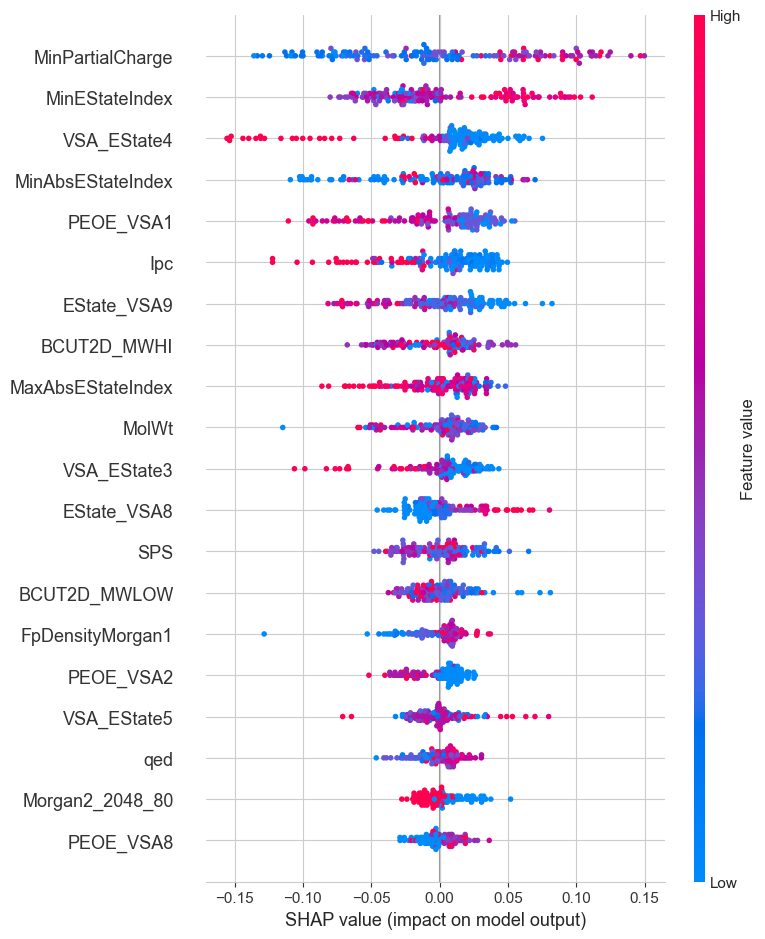


Top 10 SHAP features:
MinPartialCharge     0.059003
MinEStateIndex       0.039234
VSA_EState4          0.034950
MinAbsEStateIndex    0.032534
PEOE_VSA1            0.030348
Ipc                  0.027624
EState_VSA9          0.027340
BCUT2D_MWHI          0.021631
MaxAbsEStateIndex    0.021120
MolWt                0.018615

Top 10 K-Best features:
PEOE_VSA1            31.236845
MinPartialCharge     17.394008
MaxAbsEStateIndex    15.126855
EState_VSA8          13.494302
PEOE_VSA2            13.362057
PEOE_VSA14           13.040548
VSA_EState3          11.503315
EState_VSA9          10.332607
MinEStateIndex        9.030612
VSA_EState5           7.810735

Top 10 Lasso features:
EState_VSA8        0.905024
Ipc                0.768063
PEOE_VSA1          0.738035
Morgan2_2048_80    0.660770
qed                0.485940
PEOE_VSA2          0.434243
MinEStateIndex     0.428158
VSA_EState3        0.421709
BCUT2D_MWHI        0.320393
PEOE_VSA8          0.297166


In [8]:
import shap
from sklearn.feature_selection import mutual_info_classif


# === 2. SHAP Importance ===
# SHAP ti ukazuje, ako každý príznak (MACCS bit) prispieva ku konečnej predikcii.
# Je to najinterpretovateľnejšia metóda (globálne aj lokálne).
f = lambda X: base_model.predict_proba(X)[:, 1]

explainer = shap.Explainer(f, X_train)
shap_result = explainer(X_train, max_evals=2 * X_train.shape[1] + 50)

shap_values = shap_result.values
shap_importance = np.abs(shap_values).mean(axis=0)

shap_features = pd.Series(shap_importance, index=X_train.columns).sort_values(ascending=False)


# === 3. Mutual Information (MI) ===
# MI meria, koľko informácie nesie každý príznak o cieľovej triede.
# Je veľmi stabilná metóda pre malé datasety a zmiešané typy príznakov.
mi_scores = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=42)

mi_features = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)


# === 4. ANOVA F-score (SelectKBest) ===
# ANOVA porovnáva priemerné hodnoty príznakov medzi triedami.
# Je to čistý štatistický pohľad – nezávislý od modelu.
kbest = SelectKBest(score_func=f_classif, k='all')
kbest.fit(X_train, y_train)
kbest_scores = pd.Series(kbest.scores_, index=X_train.columns).fillna(0)
kbest_features = kbest_scores.sort_values(ascending=False)

# === 5. Lasso Logistic Regression (L1 koeficienty) ===
# Lasso dáva lineárny pohľad na dôležitosť príznakov – veľké koeficienty = dôležitý príznak.
# Veľkou výhodou je, že zriedi nepotrebné príznaky (robí sparse model).
lasso = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000
)
lasso.fit(X_train, y_train)

lasso_importance = pd.Series(np.abs(lasso.coef_).ravel(), index=X_train.columns)
lasso_features = lasso_importance.sort_values(ascending=False)

# === 6. vizualizácia ===
shap.summary_plot(shap_values, X_train)

# Print best features for each method
print("\nTop 10 SHAP features:")
print(shap_features.head(10).to_string())
print("\nTop 10 K-Best features:")
print(kbest_features.head(10).to_string())
print("\nTop 10 Lasso features:")
print(lasso_features.head(10).to_string())



## Evaluate Feature Method

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_rf_feature_method(method_name, feature_ranking, X_train, y_train, rf_model):
    """
    Универсальная функция кросс-валидации для Random Forest.
    method_name: 'SHAP', 'RF', 'KBest', 'Lasso'
    feature_ranking: pd.Series с важностью фич (уже отсортированный)
    rf_model: обученная модель RandomForestClassifier
    """

    print(f"\n===== Evaluating {method_name} feature ranking =====")

    results = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Цикл top-N: 5, 10, 15, ..., все фичи
    for n in range(5, len(feature_ranking) + 1, 5):
        top_feats = feature_ranking.head(n).index.tolist()

        # Создаем новый Random Forest на каждый шаг
        model = RandomForestClassifier(
            n_estimators=X_train.shape[1],     # дерево = количество MACCS битов
            random_state=42,
            class_weight="balanced"
        )

        # Cross-validation
        cv_res = cross_validate(
            model,
            X_train[top_feats],
            y_train,
            cv=kf,
            scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"},
            n_jobs=-1,
            return_train_score=False
        )

        mean_acc = cv_res["test_accuracy"].mean()
        mean_f1 = cv_res["test_f1"].mean()
        mean_auc = cv_res["test_roc_auc"].mean()

        results.append((n, mean_acc, mean_f1, mean_auc))

    # Таблица
    res_df = pd.DataFrame(results, columns=["Top_N", "CV_Accuracy", "CV_F1", "CV_ROC_AUC"])

    # Лучший N по F1
    best = res_df.iloc[res_df["CV_F1"].idxmax()]
    best_n = int(best.Top_N)

    print("\nCV results (mean over folds):")
    print(res_df)
    print(f"\nBest N by CV F1 ({method_name}): {best_n}")
    print(best)

    # График
    plt.figure(figsize=(7, 4))
    plt.plot(res_df["Top_N"], res_df["CV_Accuracy"], label="CV Accuracy")
    plt.plot(res_df["Top_N"], res_df["CV_F1"], label="CV F1")
    plt.plot(res_df["Top_N"], res_df["CV_ROC_AUC"], label="CV ROC AUC")
    plt.xlabel(f"Number of top {method_name} features")
    plt.ylabel("Mean CV score")
    plt.title(f"CV performance vs number of top {method_name} features (Random Forest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return best_n, res_df


===== Evaluating SHAP feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5     0.787742  0.831238    0.840127
1     10     0.821075  0.861556    0.858208
2     15     0.827527  0.870322    0.850679
3     20     0.833978  0.874333    0.843273
4     25     0.820860  0.863368    0.843184
5     30     0.801075  0.848711    0.827658

Best N by CV F1 (SHAP): 20
Top_N          20.000000
CV_Accuracy     0.833978
CV_F1           0.874333
CV_ROC_AUC      0.843273
Name: 3, dtype: float64


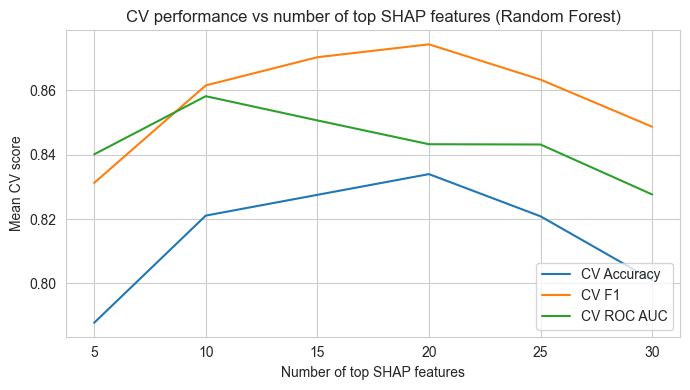


===== Evaluating MI feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5     0.767527  0.820927    0.769132
1     10     0.794409  0.837960    0.854636
2     15     0.794194  0.841620    0.854730
3     20     0.794194  0.836624    0.840754
4     25     0.794409  0.840963    0.837565
5     30     0.774409  0.827658    0.825187

Best N by CV F1 (MI): 15
Top_N          15.000000
CV_Accuracy     0.794194
CV_F1           0.841620
CV_ROC_AUC      0.854730
Name: 2, dtype: float64


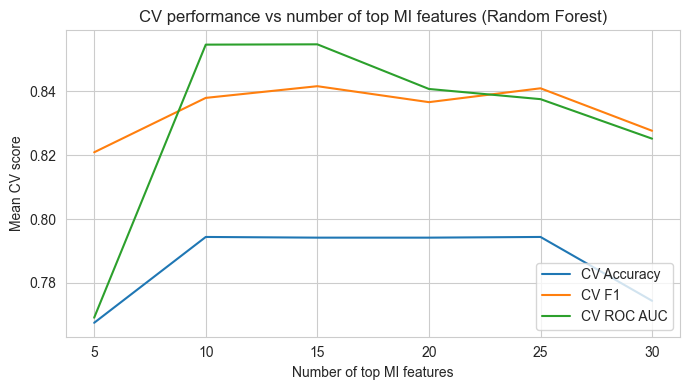


===== Evaluating KBest feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5     0.801075  0.844151    0.820804
1     10     0.814194  0.858095    0.863431
2     15     0.827097  0.868248    0.850938
3     20     0.768172  0.822425    0.825266
4     25     0.800860  0.848656    0.849720
5     30     0.801075  0.850415    0.834557

Best N by CV F1 (KBest): 15
Top_N          15.000000
CV_Accuracy     0.827097
CV_F1           0.868248
CV_ROC_AUC      0.850938
Name: 2, dtype: float64


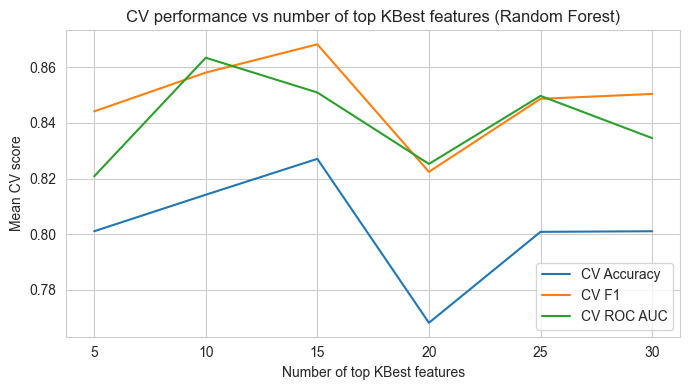


===== Evaluating Lasso feature ranking =====

CV results (mean over folds):
   Top_N  CV_Accuracy     CV_F1  CV_ROC_AUC
0      5     0.741505  0.804678    0.756600
1     10     0.807742  0.853626    0.809440
2     15     0.801075  0.848504    0.823031
3     20     0.821075  0.865651    0.845565
4     25     0.787742  0.842520    0.838380
5     30     0.794409  0.840488    0.829407

Best N by CV F1 (Lasso): 20
Top_N          20.000000
CV_Accuracy     0.821075
CV_F1           0.865651
CV_ROC_AUC      0.845565
Name: 3, dtype: float64


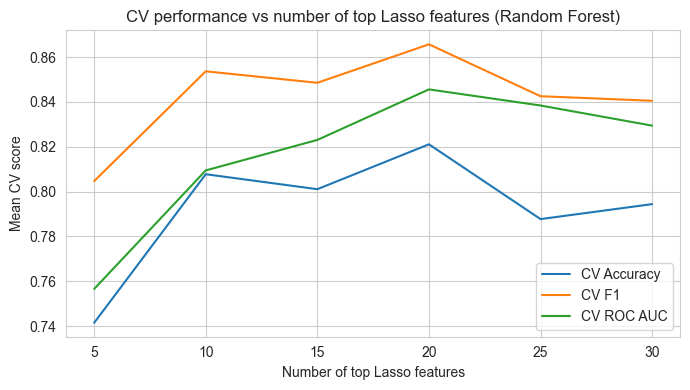

In [10]:


best_shap, shap_cv_table = evaluate_rf_feature_method(
    "SHAP", shap_features, X_train, y_train, base_model
)

best_mi, mi_cv_table = evaluate_rf_feature_method(
    "MI", mi_features, X_train, y_train, base_model
)

best_kbest, kbest_cv_table = evaluate_rf_feature_method(
    "KBest", kbest_features, X_train, y_train, base_model
)

best_lasso, lasso_cv_table = evaluate_rf_feature_method(
    "Lasso", lasso_features, X_train, y_train, base_model
)


## Train Model Features

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_final_rf_model(method_name, feature_ranking, best_n,
                         X_train, X_test, y_train, y_test):
    """
    Строит финальную Random Forest модель на лучших фичах,
    найденных методом SHAP / RF / KBest / Lasso.

    method_name: строка ('SHAP', 'RF', 'KBest', 'Lasso')
    feature_ranking: pd.Series — ранжированные фичи
    best_n: количество лучших фич из evaluate_rf_feature_method()
    """

    print(f"\n===== FINAL Random Forest model using {best_n} {method_name} features =====")

    # выбираем топ-N фич
    top_feats = feature_ranking.head(best_n).index.tolist()

    # создаём финальную Random Forest модель
    final_model = RandomForestClassifier(
        n_estimators=best_n,      # число деревьев = число фич
        random_state=42,
        class_weight="balanced"
    )

    # обучение модели
    final_model.fit(X_train[top_feats], y_train)

    # предсказание

    y_pred = final_model.predict(X_test[top_feats])
    y_prob = final_model.predict_proba(X_test[top_feats])[:, 1]

    # считаем метрики
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    # выводим отчёт
    print(f"\nFinal model performance ({method_name}) on TEST:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")

    log_result(
    method_name,
    model_type="Baseline_RF",
    n_features=best_n,
    metrics={
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    },
    params={
        "n_estimators": X_train.shape[1],
        "class_weight": "balanced"
    },
    stage="final"
)


    # 7возвращаем модель и метрики
    return final_model, {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc,
        "Top_Features": top_feats
    }


In [12]:

final_shap_model, shap_metrics = train_final_rf_model(
    "SHAP", shap_features, best_shap, X_train, X_test, y_train, y_test
)

final_mi_model, mi_metrics = train_final_rf_model(
    "MI", mi_features, best_mi, X_train, X_test, y_train, y_test
)

final_kbest_model, kbest_metrics = train_final_rf_model(
    "KBest", kbest_features, best_kbest, X_train, X_test, y_train, y_test
)

final_lasso_model, lasso_metrics = train_final_rf_model(
    "Lasso", lasso_features, best_lasso, X_train, X_test, y_train, y_test
)



===== FINAL Random Forest model using 20 SHAP features =====

Final model performance (SHAP) on TEST:
Accuracy:  0.8158
Precision: 0.7931
Recall:    0.9583
F1 score:  0.8679
ROC AUC:   0.8095

===== FINAL Random Forest model using 15 MI features =====

Final model performance (MI) on TEST:
Accuracy:  0.7895
Precision: 0.7857
Recall:    0.9167
F1 score:  0.8462
ROC AUC:   0.7798

===== FINAL Random Forest model using 15 KBest features =====

Final model performance (KBest) on TEST:
Accuracy:  0.8158
Precision: 0.7931
Recall:    0.9583
F1 score:  0.8679
ROC AUC:   0.8036

===== FINAL Random Forest model using 20 Lasso features =====

Final model performance (Lasso) on TEST:
Accuracy:  0.7632
Precision: 0.7778
Recall:    0.8750
F1 score:  0.8235
ROC AUC:   0.7649


In [ ]:
shap_metrics

In [ ]:
print("n_estimators:", model.n_estimators)
print("max_depth:", model.max_depth)
print("min_samples_split:", model.min_samples_split)
print("min_samples_leaf:", model.min_samples_leaf)
print("max_features:", model.max_features)


## Optuna

In [13]:
def tune_rf_optuna(method_name, feature_ranking, best_n,
                   X_train, X_test, y_train, y_test, n_trials=100):

    top_feats = feature_ranking.head(best_n).index.tolist()
    X_train_fs = X_train[top_feats]
    X_test_fs  = X_test[top_feats]

    optuna.logging.set_verbosity(optuna.logging.ERROR)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 60, 160),
            "max_depth": trial.suggest_int("max_depth", 4, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 6),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.1, 0.2]),
            "bootstrap": True,
            "class_weight": "balanced",
            "random_state": 42,
            "n_jobs": -1,
        }

        model = RandomForestClassifier(**params)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc = cross_val_score(
            model, X_train_fs, y_train,
            cv=cv, scoring="roc_auc", n_jobs=-1
        ).mean()

        return auc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params

    final_model = RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_fs, y_train)

    y_pred = final_model.predict(X_test_fs)
    y_prob = final_model.predict_proba(X_test_fs)[:, 1]

    return {
        "Method": method_name,
        "Model": "RandomForest",
        "Feature_Ranking": feature_ranking,
        "Best_N": best_n,
        "AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Params": study.best_params,
    }


## Model Feautures Tunning (Optuna + gboost)

In [14]:
def tune_advanced_tree_model(method_name, feature_ranking, best_n,
                             X_train, X_test, y_train, y_test,
                             model_type="gboost", n_trials=50):

    top_feats = feature_ranking.head(best_n).index.tolist()
    X_train_fs = X_train[top_feats]
    X_test_fs  = X_test[top_feats]

    optuna.logging.set_verbosity(optuna.logging.ERROR)

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 80, 250),
            "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15),
            "max_depth": trial.suggest_int("max_depth", 2, 4),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 6),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        }

        model = GradientBoostingClassifier(**params)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc = cross_val_score(
            model,
            X_train_fs,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        ).mean()

        return auc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params

    final_model = GradientBoostingClassifier(random_state=42, **best_params)
    final_model.fit(X_train_fs, y_train)

    y_pred = final_model.predict(X_test_fs)
    y_prob = final_model.predict_proba(X_test_fs)[:, 1]

    return {
        "Method": method_name,
        "Model": "RandomForest",
        "Feature_Ranking": feature_ranking,
        "Best_N": best_n,
        "AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Params": study.best_params,
    }



## Result

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

methods = {
    "SHAP": (shap_features, best_shap),
    "MI": (mi_features, best_mi),
    "KBest": (kbest_features, best_kbest),
    "Lasso": (lasso_features, best_lasso),
}

rf_rows = []
# gb_rows = []

for name, (ranking, best_n) in methods.items():

    rf_rows.append(
        tune_rf_optuna(name, ranking, best_n,
                       X_train, X_test, y_train, y_test)
    )

    # gb_rows.append(
    #     tune_advanced_tree_model(name, ranking, best_n,
    #                              X_train, X_test, y_train, y_test,
    #                              model_type="gboost")
    # )

# Таблицы
rf_results_df = pd.DataFrame(rf_rows)
# gb_results_df = pd.DataFrame(gb_rows)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [16]:
rf_results_df

,Method,Model,Feature_Ranking,Best_N,AUC,Accuracy,Precision,Recall,F1,Params
0,SHAP,RandomForest,MinPartialCharge 0.059003 MinEStateIndex ...,20,0.821429,0.842105,0.821429,0.958333,0.884615,"{'n_estimators': 71, 'max_depth': 7, 'min_samp..."
1,MI,RandomForest,MinPartialCharge 0.222748 PEOE_VSA2 ...,15,0.785714,0.763158,0.800000,0.833333,0.816327,"{'n_estimators': 91, 'max_depth': 8, 'min_samp..."
2,KBest,RandomForest,PEOE_VSA1 31.236845 MinPartialCharg...,15,0.785714,0.815789,0.793103,0.958333,0.867925,"{'n_estimators': 76, 'max_depth': 7, 'min_samp..."
3,Lasso,RandomForest,EState_VSA8 0.905024 Ipc ...,20,0.812500,0.789474,0.807692,0.875000,0.840000,"{'n_estimators': 67, 'max_depth': 8, 'min_samp..."


In [17]:
# gb_results_df

,Method,Model,Feature_Ranking,Best_N,AUC,Accuracy,Precision,Recall,F1,Params
0,SHAP,RandomForest,MinPartialCharge 0.059003 MinEStateIndex ...,20,0.744048,0.763158,0.777778,0.875000,0.823529,"{'n_estimators': 126, 'learning_rate': 0.03095..."
1,MI,RandomForest,MinPartialCharge 0.222748 PEOE_VSA2 ...,15,0.723214,0.736842,0.769231,0.833333,0.800000,"{'n_estimators': 101, 'learning_rate': 0.11634..."
2,KBest,RandomForest,PEOE_VSA1 31.236845 MinPartialCharg...,15,0.758929,0.684211,0.750000,0.750000,0.750000,"{'n_estimators': 119, 'learning_rate': 0.10604..."
3,Lasso,RandomForest,EState_VSA8 0.905024 Ipc ...,20,0.758929,0.842105,0.821429,0.958333,0.884615,"{'n_estimators': 142, 'learning_rate': 0.03808..."


In [19]:
best_rf_row = rf_results_df.loc[rf_results_df["AUC"].idxmax()]
rf_best_params = best_rf_row["Params"]
rf_best_n = best_rf_row["Best_N"]
rf_best_method = best_rf_row["Method"]

# best_gb_row = gb_results_df.loc[gb_results_df["AUC"].idxmax()]
# gb_best_params = best_gb_row["Params"]
# gb_best_n = best_gb_row["Best_N"]
# gb_best_method = best_gb_row["Method"]

print("Best RF:", rf_best_method, rf_best_n, rf_best_params)
# print("Best GB:", gb_best_method, gb_best_n, gb_best_params)


Best RF: SHAP 20 {'n_estimators': 71, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.1}


In [22]:
shap_metrics = rf_results_df[rf_results_df["Method"] == "SHAP"].iloc[0]

print({
    "Method": shap_metrics["Method"],
    "Model": shap_metrics["Model"],
    "Best_N": shap_metrics["Best_N"],
    "AUC": shap_metrics["AUC"],
    "Accuracy": shap_metrics["Accuracy"],
    "Precision": shap_metrics["Precision"],
    "Recall": shap_metrics["Recall"],
    "F1": shap_metrics["F1"],
    "Params": shap_metrics["Params"]
})

{'Method': 'SHAP', 'Model': 'RandomForest', 'Best_N': np.int64(20), 'AUC': np.float64(0.8214285714285714), 'Accuracy': np.float64(0.8421052631578947), 'Precision': np.float64(0.8214285714285714), 'Recall': np.float64(0.9583333333333334), 'F1': np.float64(0.8846153846153846), 'Params': {'n_estimators': 71, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.1}}


## Dinamic


=== Testing top 5 SHAP features ===
Best parameters: {'n_estimators': np.int64(60), 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.3, 'max_depth': None, 'bootstrap': True}
Accuracy: 0.763 | ROC-AUC: 0.812

=== Testing top 6 SHAP features ===
Best parameters: {'n_estimators': np.int64(40), 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 4, 'bootstrap': True}
Accuracy: 0.763 | ROC-AUC: 0.804

=== Testing top 7 SHAP features ===
Best parameters: {'n_estimators': np.int64(20), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 6, 'bootstrap': True}
Accuracy: 0.789 | ROC-AUC: 0.754

=== Testing top 8 SHAP features ===
Best parameters: {'n_estimators': np.int64(20), 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 7, 'bootstrap': True}
Accuracy: 0.737 | ROC-AUC: 0.798

=== Testing top 9 SHAP features ===
Best parameters: {'n_estimators': np.int64(120), 'min_samples_split': 5,

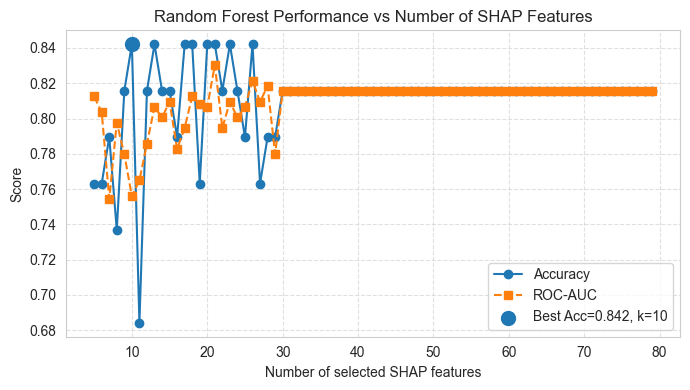


Best Accuracy = 0.842, ROC-AUC = 0.756, k = 10


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

# Ранжирование признаков (SHAP)
ranking = shap_features   # Series: feature -> importance

# Гиперпараметры для Random Forest
param_dist = {
    "n_estimators": np.arange(20, 160, 20),
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
}

results = []

# Sweep по числу признаков
for k in range(5, 80, 1):
    print(f"\n=== Testing top {k} SHAP features ===")

    # Выбор top-k фичей
    top_feats = ranking.head(k).index.tolist()
    X_train_sel = X_train[top_feats]
    X_test_sel = X_test[top_feats]

    # Модель
    rf_clf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=60,
        scoring="accuracy",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_sel, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    y_prob = best_model.predict_proba(X_test_sel)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append((k, acc, auc))

    print(f"Best parameters: {search.best_params_}")
    print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")

# Анализ результатов
results = np.array(results)
feature_counts = results[:, 0]
accuracies = results[:, 1]
auc_scores = results[:, 2]

# Лучший по Accuracy
best_index = np.argmax(accuracies)
best_k = int(feature_counts[best_index])
best_acc = accuracies[best_index]
best_auc = auc_scores[best_index]

# Графики
plt.figure(figsize=(7, 4))
plt.plot(feature_counts, accuracies, 'o-', label='Accuracy')
plt.plot(feature_counts, auc_scores, 's--', label='ROC-AUC')
plt.scatter(best_k, best_acc, s=100, zorder=5,
            label=f'Best Acc={best_acc:.3f}, k={best_k}')
plt.title('Random Forest Performance vs Number of SHAP Features')
plt.xlabel('Number of selected SHAP features')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Accuracy = {best_acc:.3f}, ROC-AUC = {best_auc:.3f}, k = {best_k}")



=== Testing top 5 SHAP features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': 3, 'bootstrap': False}
Accuracy: 0.636 | ROC-AUC: 0.711

=== Testing top 6 SHAP features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3, 'bootstrap': False}
Accuracy: 0.667 | ROC-AUC: 0.717

=== Testing top 7 SHAP features ===
Best parameters: {'n_estimators': np.int64(40), 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 4, 'bootstrap': False}
Accuracy: 0.697 | ROC-AUC: 0.724

=== Testing top 8 SHAP features ===
Best parameters: {'n_estimators': np.int64(40), 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 4, 'bootstrap': True}
Accuracy: 0.576 | ROC-AUC: 0.683

=== Testing top 9 SHAP features ===
Best parameters: {'n_estimators': np.int64(20), 'min_samples_split'

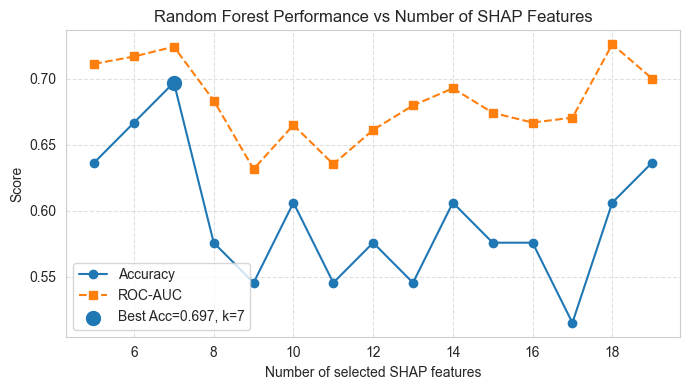


Best Accuracy = 0.697, ROC-AUC = 0.724, k = 7


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

# Ранжирование признаков (SHAP)
ranking = lasso_features   # Series: feature -> importance

# Гиперпараметры для Random Forest
param_dist = {
    "n_estimators": np.arange(20, 160, 20),
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
}

results = []

# Sweep по числу признаков
for k in range(5, 20, 1):
    print(f"\n=== Testing top {k} SHAP features ===")

    # Выбор top-k фичей
    top_feats = ranking.head(k).index.tolist()
    X_train_sel = X_train[top_feats]
    X_test_sel = X_test[top_feats]

    # Модель
    rf_clf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=60,
        scoring="accuracy",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_sel, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    y_prob = best_model.predict_proba(X_test_sel)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append((k, acc, auc))

    print(f"Best parameters: {search.best_params_}")
    print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")

# Анализ результатов
results = np.array(results)
feature_counts = results[:, 0]
accuracies = results[:, 1]
auc_scores = results[:, 2]

# Лучший по Accuracy
best_index = np.argmax(accuracies)
best_k = int(feature_counts[best_index])
best_acc = accuracies[best_index]
best_auc = auc_scores[best_index]

# Графики
plt.figure(figsize=(7, 4))
plt.plot(feature_counts, accuracies, 'o-', label='Accuracy')
plt.plot(feature_counts, auc_scores, 's--', label='ROC-AUC')
plt.scatter(best_k, best_acc, s=100, zorder=5,
            label=f'Best Acc={best_acc:.3f}, k={best_k}')
plt.title('Random Forest Performance vs Number of SHAP Features')
plt.xlabel('Number of selected SHAP features')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Accuracy = {best_acc:.3f}, ROC-AUC = {best_auc:.3f}, k = {best_k}")



=== Testing top 5 SHAP features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 3, 'bootstrap': False}
Accuracy: 0.667 | ROC-AUC: 0.691

=== Testing top 6 SHAP features ===
Best parameters: {'n_estimators': np.int64(60), 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}
Accuracy: 0.576 | ROC-AUC: 0.678

=== Testing top 7 SHAP features ===
Best parameters: {'n_estimators': np.int64(60), 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 6, 'bootstrap': True}
Accuracy: 0.636 | ROC-AUC: 0.741

=== Testing top 8 SHAP features ===
Best parameters: {'n_estimators': np.int64(100), 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 4, 'bootstrap': True}
Accuracy: 0.606 | ROC-AUC: 0.681

=== Testing top 9 SHAP features ===
Best parameters: {'n_estimators': np.int64(60), 'min_samples_split'

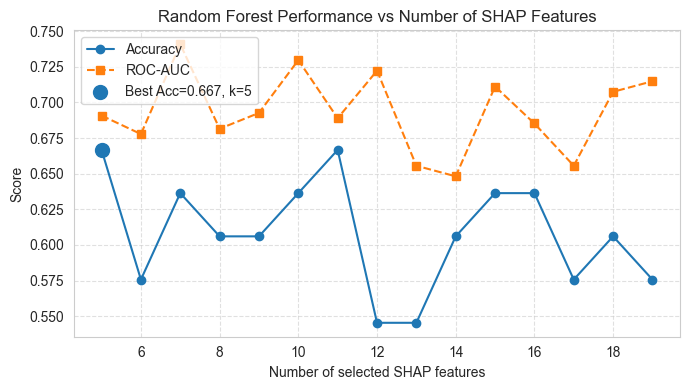


Best Accuracy = 0.667, ROC-AUC = 0.691, k = 5


In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

# Ранжирование признаков (SHAP)
ranking = mi_features   # Series: feature -> importance

# Гиперпараметры для Random Forest
param_dist = {
    "n_estimators": np.arange(20, 160, 20),
    "max_depth": [3, 4, 5, 6, 7, None],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "bootstrap": [True, False],
}

results = []

# Sweep по числу признаков
for k in range(5, 20, 1):
    print(f"\n=== Testing top {k} SHAP features ===")

    # Выбор top-k фичей
    top_feats = ranking.head(k).index.tolist()
    X_train_sel = X_train[top_feats]
    X_test_sel = X_test[top_feats]

    # Модель
    rf_clf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=60,
        scoring="accuracy",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_sel, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_sel)
    y_prob = best_model.predict_proba(X_test_sel)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append((k, acc, auc))

    print(f"Best parameters: {search.best_params_}")
    print(f"Accuracy: {acc:.3f} | ROC-AUC: {auc:.3f}")

# Анализ результатов
results = np.array(results)
feature_counts = results[:, 0]
accuracies = results[:, 1]
auc_scores = results[:, 2]

# Лучший по Accuracy
best_index = np.argmax(accuracies)
best_k = int(feature_counts[best_index])
best_acc = accuracies[best_index]
best_auc = auc_scores[best_index]

# Графики
plt.figure(figsize=(7, 4))
plt.plot(feature_counts, accuracies, 'o-', label='Accuracy')
plt.plot(feature_counts, auc_scores, 's--', label='ROC-AUC')
plt.scatter(best_k, best_acc, s=100, zorder=5,
            label=f'Best Acc={best_acc:.3f}, k={best_k}')
plt.title('Random Forest Performance vs Number of SHAP Features')
plt.xlabel('Number of selected SHAP features')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Accuracy = {best_acc:.3f}, ROC-AUC = {best_auc:.3f}, k = {best_k}")


Tento kód postupne prechádza rôzne počty najdôležitejších SHAP-príznakov (od 5 do 79) a pre každý takýto výber spúšťa RandomizedSearchCV, ktorý hľadá najlepšiu konfiguráciu hyperparametrov pre Random Forest. Vďaka tomu sa zároveň optimalizuje aj samotná veľkosť príznakového priestoru – teda zisťuje sa, koľko príznakov modelu skutočne pomáha. Analýza ukazuje, že najvyššia presnosť sa dosiahla pri 79 SHAP príznakoch, kde model dosiahol Accuracy = 0.727 a ROC-AUC = 0.730, čo znamená, že väčší počet SHAP príznakov zachytáva viac informácie bez pretrénovania. Záverečný graf vizuálne ukazuje trend metrík pri narastajúcom počte príznakov a pomáha vybrať optimálne množstvo pre finálny model.

In [23]:
final_table = save_results_table("../all_results.xlsx")
print(final_table)

Saved full results table to all_results.xlsx
   Method        Model          Stage  Top_Features  Accuracy  Precision  \
0    SHAP  Baseline_RF          final             5  0.636364   0.666667   
1      MI  Baseline_RF          final            10  0.636364   0.714286   
2   KBest  Baseline_RF          final            15  0.636364   0.687500   
3   Lasso  Baseline_RF          final            10  0.606061   0.647059   
4    SHAP    Optuna_RF         optuna             5  0.666667   0.705882   
5      MI    Optuna_RF         optuna            10  0.606061   0.692308   
6   KBest    Optuna_RF         optuna            15  0.606061   0.666667   
7   Lasso    Optuna_RF         optuna            10  0.606061   0.631579   
8    SHAP   extratrees  simple_tuning             5  0.606061   0.647059   
9      MI   extratrees  simple_tuning             5  0.636364   0.650000   
10  KBest   extratrees  simple_tuning             5  0.636364   0.666667   
11  Lasso   extratrees  simple_tuning      